<h1 style="text-align: center;">[Your Project Title]</h1>
<h3 style="text-align: center;">[Your Name]</h3>

---

## **Section 0. Setup**

> 🎯 *Tujuan:* Menyiapkan environment kerja (import library, konfigurasi global) supaya proses selanjutnya konsisten dan reproducible.

**0.1 Import Library**

> 🎯 *Tujuan:* Memuat semua library yang dibutuhkan di satu tempat di awal, supaya dependency notebook mudah dilacak.

In [ ]:
# import library dasar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# tambahkan import lain sesuai kebutuhan (sklearn, dll) di sini
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import FunctionTransformer, RobustScaler, OneHotEncoder, PowerTransformer

from sklearn.feature_selection import SelectFromModel

from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier, PassiveAggressiveClassifier
from sklearn.svm import LinearSVC, SVC

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

**0.2 Global Configuration**

> 🎯 *Tujuan:* Menetapkan parameter global seperti random_state di satu tempat, supaya semua proses (split, model, CV) memakai nilai yang sama.

> 📌 **Catatan untuk Peserta:** Selalu set `RANDOM_STATE` di satu tempat dan pakai variabel yang sama di semua proses (train_test_split, model, cross-validation). Ini membuat hasil eksperimenmu **reproducible** — orang lain (atau kamu sendiri, minggu depan) bisa menjalankan ulang notebook dan dapat hasil yang sama persis.

In [ ]:
RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

df =  pd.read_csv(r"..\\data\\raw\\data_bank_marketing_campaign.csv")

## **Section 1. Business Understanding**

> 🎯 *Tujuan:* Menerjemahkan masalah bisnis menjadi masalah yang bisa diselesaikan dengan machine learning, sebelum menyentuh data sama sekali.

**1.1 Context**

> 🎯 Bank merupakan salah satu Lembaga keuangan yang menawarkan berbagai produk kepada Masyarakat, seperti Tabungan, kredit, investasi, dan deposito berjangka (term deposit). Salah satu produk investasi yang banyak ditawarkan adalah deposito berjangka, yaitu simpanan yang hanya dapat cair stelah jangka waktu tertentu dengan memberi hasil berupa bunga tetap.
Dalam industri perbankan yang semakin kompetitif, mempertahankan nasabah lama sekaligus memperoleh nasabah baru menjadi tantangan utama. Salah satu strategi yang umum dilakukan ialah marketing campaign, yaitu kegiatan promosi yang dilakukan melalui telepon atau media komunikasi lainnya untuk menawarkan produk deposito kepada calon nasabah.
Namun, pelaksanaan marketing campaign membutuhkan biaya dan sumber daya yang cukup besar. Tidak semua calon nasabah yang dihubungi akan tertarik untuk membuka deposito. Oleh sebab itu, bank perlu mengidentifikasi pelanggan yang memiliki peluang tinggi untuk menerima penawaran sehingga marketing campaign dapat berjaalan lebih efektif dan efisien.
Melalui analisis data historis pelanggan dan aktivitas marketing campaign, Perusahaan dapat membangun model prediksi yang membantu menentukan pelanggan yang berpotensi untuk dihubungi pada kampanye berikutnya.
Stakeholder :
Marketing tim : Menentukan strategi marketing campaign
Sales tim : Melakukan komunikasi langsung kepada calon nasabah 


**1.2 Problem Statements**

> 🎯 *Tujuan:* Merumuskan masalah secara spesifik dan terukur, biasanya dalam bentuk pertanyaan yang bisa dijawab lewat data.

**1.3 Goals**

> 🎯 *Tujuan:* Menetapkan target yang ingin dicapai proyek ini, sebagai turunan langsung dari problem statement di atas.

**1.4 Analytical Approach**

> 🎯 *Tujuan:* Menentukan pendekatan analitis/teknis (misal klasifikasi atau regresi) yang akan dipakai untuk mencapai goals.

**1.5 Metric Evaluation (Business Metric, Machine Learning Evaluation Metric)**

> 🎯 *Tujuan:* Menjembatani metrik bisnis (misal estimasi kerugian) dengan metrik ML (misal precision/recall) yang nanti dipakai mengevaluasi model.

**1.6 Success Criteria**

> 🎯 *Tujuan:* Menetapkan ambang batas angka (misal minimal recall 80%) yang menentukan apakah model dianggap layak dipakai.

## **Section 2. Data Understanding**

> 🎯 *Tujuan:* Mengenali data secara umum — bentuk, tipe, dan makna tiap fitur — sebelum melakukan pembersihan atau analisis mendalam.

**2.1 General Information**

> 🎯 *Tujuan:* Melihat ukuran, tipe data, dan struktur umum dataset (jumlah baris, kolom, tipe data tiap kolom).

In [ ]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 7813 entries, 0 to 7812
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   age       7813 non-null   int64
 1   job       7813 non-null   str  
 2   balance   7813 non-null   int64
 3   housing   7813 non-null   str  
 4   loan      7813 non-null   str  
 5   contact   7813 non-null   str  
 6   month     7813 non-null   str  
 7   campaign  7813 non-null   int64
 8   pdays     7813 non-null   int64
 9   poutcome  7813 non-null   str  
 10  deposit   7813 non-null   str  
dtypes: int64(4), str(7)
memory usage: 932.4 KB


,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
0,55,admin.,1662,no,no,cellular,jun,2,-1,unknown,yes
1,39,self-employed,-3058,yes,yes,cellular,apr,3,-1,unknown,yes
2,51,admin.,3025,no,no,cellular,may,1,352,other,yes
3,38,services,-87,yes,no,cellular,may,1,-1,unknown,no
4,36,housemaid,205,yes,no,telephone,nov,4,-1,unknown,no


**2.2 Feature Information**

> 🎯 *Tujuan:* Mendokumentasikan makna tiap fitur dan relevansinya terhadap masalah bisnis di Section 1.

| Feature | Description | Impact to Business |
|---------| ----------- | ------------------ |
| *contoh:* `annual_income` | *Pendapatan tahunan pemohon pinjaman* | *Semakin tinggi income, semakin besar kapasitas bayar → berkorelasi dengan risiko gagal bayar* |

> 📌 Baris contoh di atas menunjukkan pola pengisian: kolom terakhir bukan sekadar deskripsi ulang, tapi jawaban dari *"kenapa fitur ini penting buat masalah bisnis di Section 1?"*. Hapus baris contoh dan isi dengan fitur asli datasetmu.

**2.3 Statistics Summary**

> 🎯 *Tujuan:* Melihat ringkasan statistik deskriptif (mean, median, min-max, dsb) untuk menangkap gambaran awal distribusi data.

In [ ]:
df.describe(include='all')

,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
count,7813.000000,7813,7813.000000,7813,7813,7813,7813,7813.000000,7813.000000,7813,7813
unique,NaN,12,NaN,2,2,3,12,NaN,NaN,4,2
top,NaN,management,NaN,no,no,cellular,may,NaN,NaN,unknown,no
freq,NaN,1792,NaN,4140,6789,5628,1976,NaN,NaN,5819,4081
mean,41.257264,NaN,1512.448611,NaN,NaN,NaN,NaN,2.519775,51.408550,NaN,NaN
std,11.919710,NaN,3089.291831,NaN,NaN,NaN,NaN,2.727001,108.072739,NaN,NaN
min,18.000000,NaN,-6847.000000,NaN,NaN,NaN,NaN,1.000000,-1.000000,NaN,NaN
25%,32.000000,NaN,127.000000,NaN,NaN,NaN,NaN,1.000000,-1.000000,NaN,NaN
50%,39.000000,NaN,549.000000,NaN,NaN,NaN,NaN,2.000000,-1.000000,NaN,NaN
75%,49.000000,NaN,1684.000000,NaN,NaN,NaN,NaN,3.000000,40.000000,NaN,NaN


## **Section 3. Data Cleaning**

> 🎯 *Tujuan:* Memastikan data bebas dari masalah kualitas (missing value, duplikat, inkonsistensi) sebelum dipakai lebih lanjut.

**3.1 Missing Values**

> 🎯 *Tujuan:* Mengidentifikasi kolom yang punya data hilang dan menentukan strategi menanganinya (drop, imputasi, atau dibiarkan dengan alasan tertentu).

In [ ]:
df.isnull().sum()

age         0
job         0
balance     0
housing     0
loan        0
contact     0
month       0
campaign    0
pdays       0
poutcome    0
deposit     0
dtype: int64

**3.2 Duplicated Values**

> 🎯 *Tujuan:* Mengecek baris data yang terduplikasi penuh maupun sebagian (misal duplikat berdasarkan ID).

In [ ]:
df.duplicated().sum()

np.int64(8)

**3.3 Data Consistency Check**
- Spelling errors / typo pada kategori
- Inkonsistensi kapitalisasi & format penulisan
- Whitespace tersembunyi

> 🎯 *Tujuan:* Menyeragamkan penulisan nilai kategorikal supaya kategori yang sebenarnya sama tidak terbaca sebagai kategori berbeda oleh model.

> 📌 Jangan hanya cek typo. Kesalahan yang jauh lebih sering muncul di data nyata adalah inkonsistensi format, misalnya kategori yang sama tapi ditulis berbeda seperti `"Yes"`, `"yes"`, dan `"YES "` (dengan spasi tersembunyi) — ini dianggap 3 kategori berbeda oleh model kalau tidak dibersihkan.

In [ ]:
for i in df:
    print(f"==== {i} Unique Values ====")
    print(f"{df[i].unique()}\n")

==== age Unique Values ====
[55 39 51 38 36 41 37 35 57 23 33 31 53 30 46 48 25 29 28 52 49 44 42 27
 47 64 26 34 56 32 58 45 54 50 79 65 40 24 60 43 61 59 62 68 82 71 73 76
 69 20 72 22 67 19 70 75 63 93 77 80 66 21 87 81 92 88 84 83 78 74 18 85
 95 86 90]

==== job Unique Values ====
<ArrowStringArray>
[       'admin.', 'self-employed',      'services',     'housemaid',
    'technician',    'management',       'student',   'blue-collar',
  'entrepreneur',       'retired',    'unemployed',       'unknown']
Length: 12, dtype: str

==== balance Unique Values ====
[ 1662 -3058  3025 ...  4108 13901  5473]

==== housing Unique Values ====
<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str

==== loan Unique Values ====
<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str

==== contact Unique Values ====
<ArrowStringArray>
['cellular', 'telephone', 'unknown']
Length: 3, dtype: str

==== month Unique Values ====
<ArrowStringArray>
['jun', 'apr', 'may', 'nov', 'jan', 'sep', 'feb', 'mar'

As `cellular` and `telephone` is quite similar in terms of word but in here `telephone` could also be interpreted as `landline` so the data would be changed from `telephone` to `landline` to explain more in depth the difference between `cellular` and `telephone`.

In [ ]:
df["contact"] = df["contact"].apply(lambda x: "landline" if x == "telephone" else x)

In [ ]:
df["contact"].unique()

<ArrowStringArray>
['cellular', 'landline', 'unknown']
Length: 3, dtype: str

As we can see on `pdays` column there is a minus value in it `-1`. from the explanation of this column we actually can see that its not possible as `pdays` is a total of days range from from the last time they are being contacted on the previous marketing campaign.

In [ ]:
df[df["pdays"]==-1].head()

,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
0,55,admin.,1662,no,no,cellular,jun,2,-1,unknown,yes
1,39,self-employed,-3058,yes,yes,cellular,apr,3,-1,unknown,yes
3,38,services,-87,yes,no,cellular,may,1,-1,unknown,no
4,36,housemaid,205,yes,no,landline,nov,4,-1,unknown,no
5,41,admin.,-76,yes,no,cellular,apr,1,-1,unknown,no


To know why this data happened we could check the correlation between this value to other columns

In [ ]:
for i in df:
    print(f"==== {i} Unique Values ====")
    print(f"{df[df["pdays"]==-1][i].unique()}\n")

==== age Unique Values ====
[55 39 38 36 41 37 35 57 33 31 53 30 25 29 52 49 44 28 42 27 26 34 56 32
 47 58 45 50 46 51 79 65 40 48 61 59 54 62 60 68 23 82 43 76 69 72 22 24
 71 67 19 70 75 63 77 80 66 21 87 20 73 84 64 78 74 88 18 81 85 95 83 86
 90]

==== job Unique Values ====
<ArrowStringArray>
[       'admin.', 'self-employed',      'services',     'housemaid',
    'management',   'blue-collar',       'student',  'entrepreneur',
    'technician',    'unemployed',       'retired',       'unknown']
Length: 12, dtype: str

==== balance Unique Values ====
[ 1662 -3058   -87 ...  5381  4108 13901]

==== housing Unique Values ====
<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str

==== loan Unique Values ====
<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str

==== contact Unique Values ====
<ArrowStringArray>
['cellular', 'landline', 'unknown']
Length: 3, dtype: str

==== month Unique Values ====
<ArrowStringArray>
['jun', 'apr', 'may', 'nov', 'jan', 'sep', 'mar', 'aug', 'jul'

In [ ]:
df[(df["poutcome"]=="unknown")&(df["pdays"]>0)]

,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
2849,61,retired,3140,yes,yes,cellular,aug,4,98,unknown,yes
3983,26,admin.,338,no,no,cellular,oct,1,188,unknown,yes


**3.4 Identify Anomaly Values**
- Check Distribution (Numerical Variable)
- Check Cardinality (Categorical Variable)

> 🎯 *Tujuan:* Mendeteksi nilai yang secara statistik tidak wajar (outlier pada numerik, kategori dengan cardinality aneh pada kategorikal).

Distribution of Numerical Value

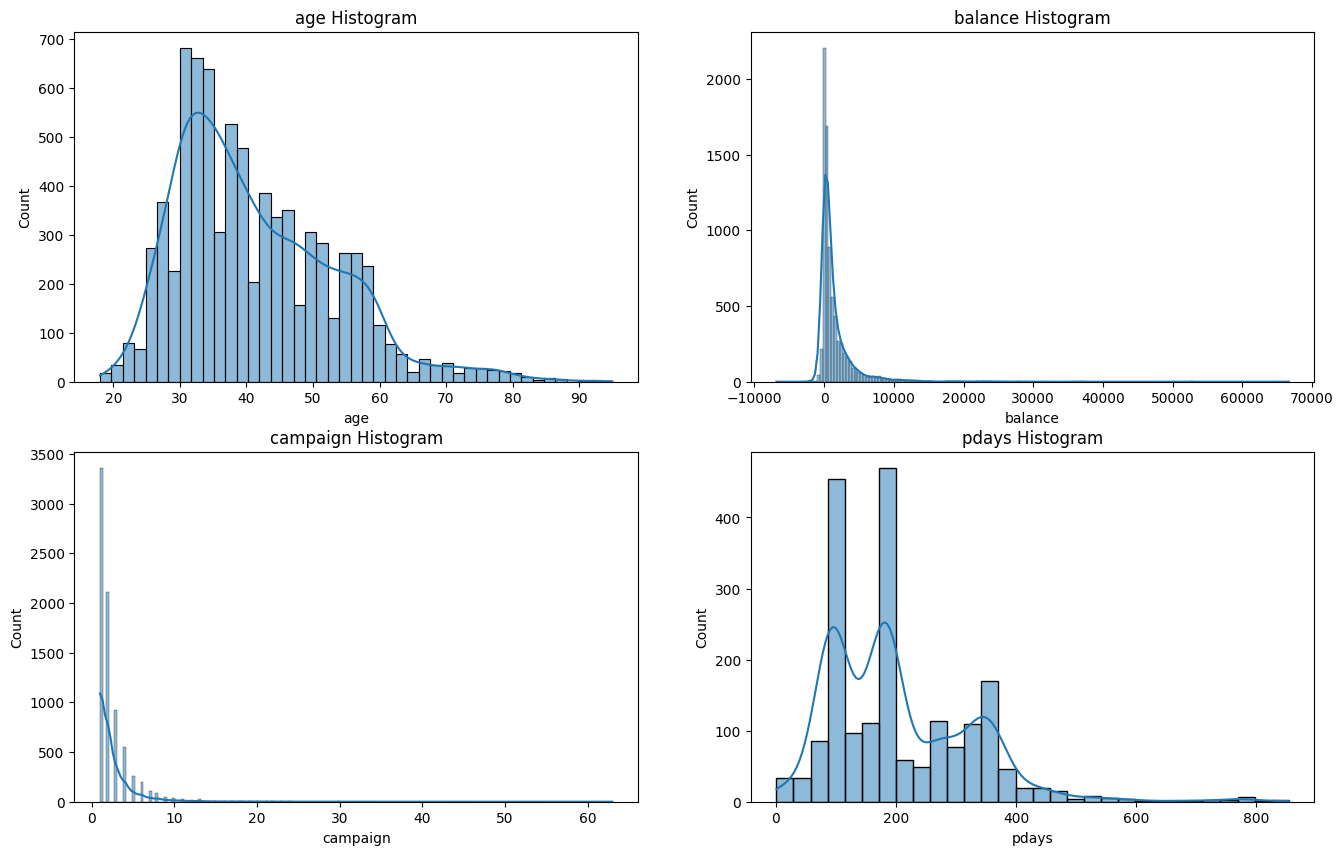

In [ ]:
num_cols = df.select_dtypes(include="number").drop(columns="pdays").columns

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes = axes.flatten()

for dex, i in enumerate(num_cols):
    sns.histplot(data=df[i], ax=axes[dex], kde=True)
    axes[dex].set_title(f"{i} Histogram")

contacted = df[df["pdays"] != -1]["pdays"]

sns.histplot(data=contacted, ax=axes[(dex + 1)], kde=True) 
axes[(dex + 1)].set_title(f"pdays Histogram")

for j in range((len(num_cols)+1), len(axes)):
    fig.delaxes(axes[j])

plt.show()

Cardinality of Categorical Value

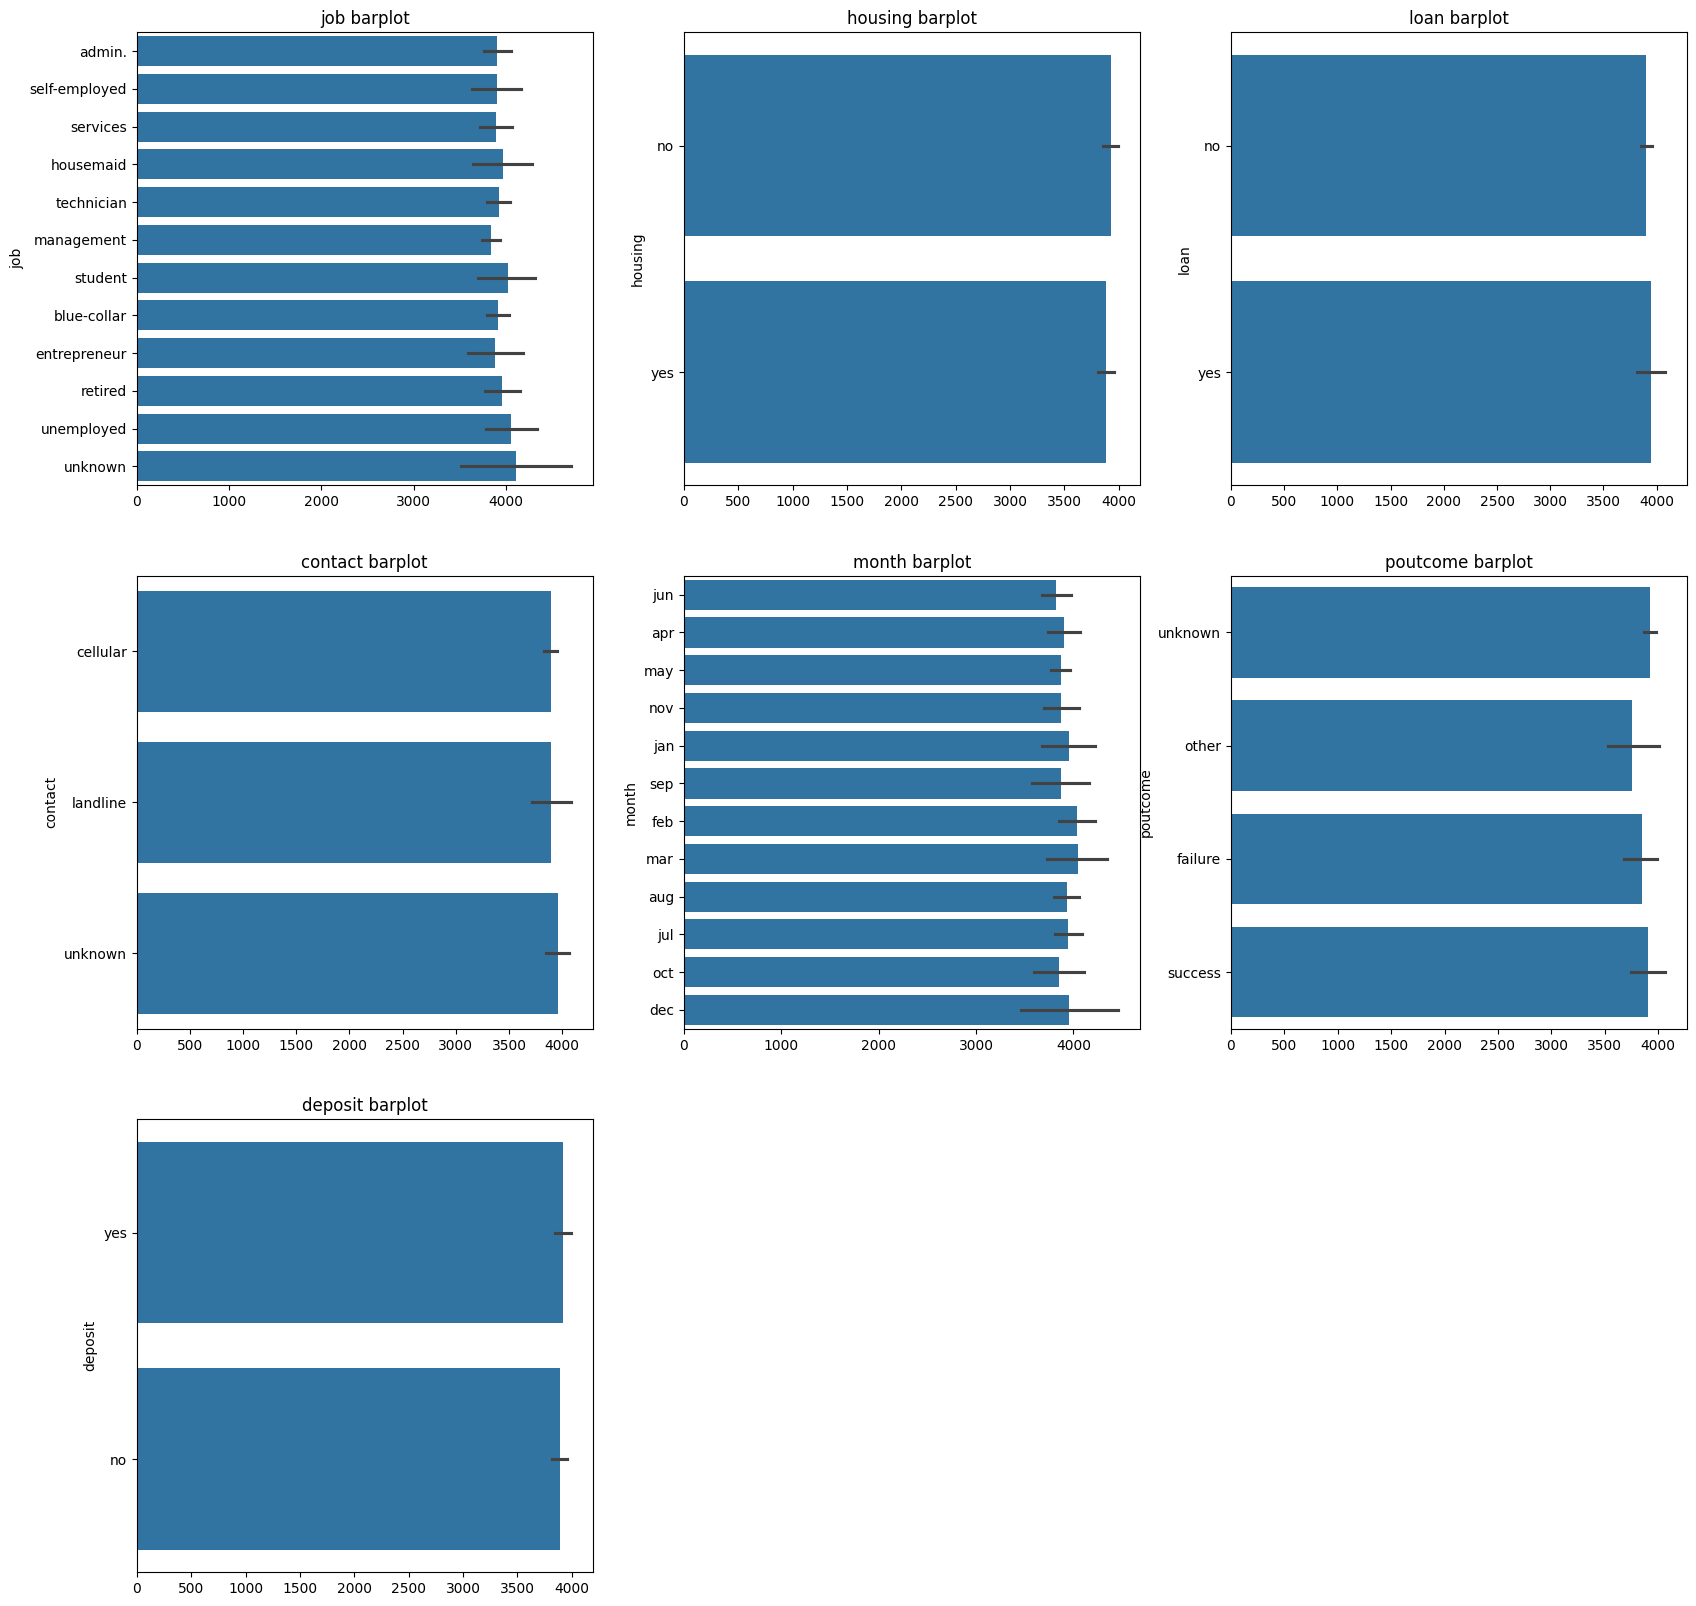

In [ ]:
cat_cols = df.select_dtypes(include="str").columns

fig, axes = plt.subplots(3, 3, figsize=(20, 20))

axes = axes.flatten()

for dex, i in enumerate(cat_cols):
    sns.barplot(data=df[i], ax=axes[dex])
    axes[dex].set_title(f"{i} barplot")

for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.show()

Outlier Values

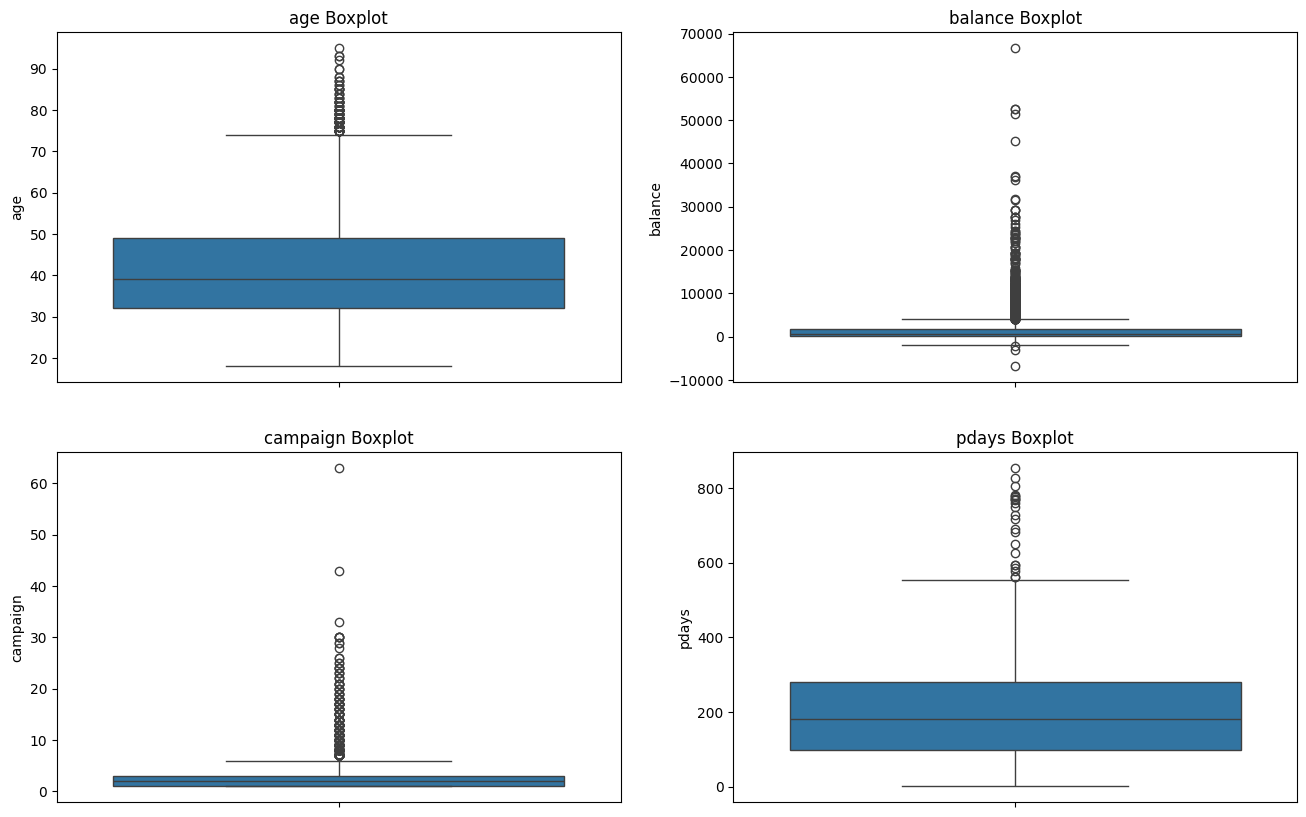

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes = axes.flatten()

for dex, i in enumerate(num_cols):
    sns.boxplot(data=df[i], ax=axes[dex])
    axes[dex].set_title(f"{i} Boxplot")

sns.boxplot(data=contacted, ax=axes[(dex + 1)]) 
axes[(dex + 1)].set_title(f"pdays Boxplot")

for j in range((len(num_cols)+1), len(axes)):
    fig.delaxes(axes[j])

plt.show()

In [ ]:
for i in df.select_dtypes(include='number').drop(columns="pdays", errors="coerce"):
    q1 =  df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)
    iqr = q3 - q1

    upper_bound = q3 + iqr * 1.5
    lower_bound = q1 - iqr * 1.5

    print(f"==== {i} Outlier ====")
    print(f"{i} column upper bound: {upper_bound}")
    print(f"{i} column lower bound: {lower_bound}")
    print(f"Total upper outlier in column {i}: {df[(df[i]>upper_bound)].shape[0]}")
    print(f"Total lower outlier in column {i}: {df[(df[i]<lower_bound)].shape[0]}\n")

q1 =  contacted.quantile(0.25)
q3 = contacted.quantile(0.75)
iqr = q3 - q1

upper_bound = q3 + iqr * 1.5
lower_bound = q1 - iqr * 1.5

print(f"==== pdays Outlier ====")
print(f"pdays column upper bound: {upper_bound}")
print(f"pdays column lower bound: {lower_bound}")
print(f"Total upper outlier in column pdays: {(contacted > upper_bound).sum()}")
print(f"Total lower outlier in column pdays: {(contacted < lower_bound).sum()}")

==== age Outlier ====
age column upper bound: 74.5
age column lower bound: 6.5
Total upper outlier in column age: 121
Total lower outlier in column age: 0

==== balance Outlier ====
balance column upper bound: 4019.5
balance column lower bound: -2208.5
Total upper outlier in column balance: 733
Total lower outlier in column balance: 3

==== campaign Outlier ====
campaign column upper bound: 6.0
campaign column lower bound: -2.0
Total upper outlier in column campaign: 429
Total lower outlier in column campaign: 0

==== pdays Outlier ====
pdays column upper bound: 555.5
pdays column lower bound: -176.5
Total upper outlier in column pdays: 23
Total lower outlier in column pdays: 0


Extreme outlier

In [ ]:
for i in df.select_dtypes(include='number').drop(columns="pdays", errors="coerce"):
    q1 =  df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)
    iqr = q3 - q1

    upper_bound = q3 + iqr * 3
    lower_bound = q1 - iqr * 3

    print(f"==== {i} Extreme Outlier ====")
    print(f"{i} column upper bound: {upper_bound}")
    print(f"{i} column lower bound: {lower_bound}")
    print(f"Total upper outlier in column {i}: {df[(df[i]>upper_bound)].shape[0]}")
    print(f"Total lower outlier in column {i}: {df[(df[i]<lower_bound)].shape[0]}\n")

q1 =  contacted.quantile(0.25)
q3 = contacted.quantile(0.75)
iqr = q3 - q1

upper_bound = q3 + iqr * 3
lower_bound = q1 - iqr * 3

print(f"==== pdays Extreme Outlier ====")
print(f"pdays column upper bound: {upper_bound}")
print(f"pdays column lower bound: {lower_bound}")
print(f"Total upper outlier in column pdays: {(contacted > upper_bound).sum()}")
print(f"Total lower outlier in column pdays: {(contacted < lower_bound).sum()}")

==== age Extreme Outlier ====
age column upper bound: 100.0
age column lower bound: -19.0
Total upper outlier in column age: 0
Total lower outlier in column age: 0

==== balance Extreme Outlier ====
balance column upper bound: 6355.0
balance column lower bound: -4544.0
Total upper outlier in column balance: 375
Total lower outlier in column balance: 1

==== campaign Extreme Outlier ====
campaign column upper bound: 9.0
campaign column lower bound: -5.0
Total upper outlier in column campaign: 190
Total lower outlier in column campaign: 0

==== pdays Extreme Outlier ====
pdays column upper bound: 830.0
pdays column lower bound: -451.0
Total upper outlier in column pdays: 1
Total lower outlier in column pdays: 0


Skewness

In [ ]:
for i in df.select_dtypes(include='number').drop(columns="pdays", errors="coerce"):
    print(f"==== {i} Skewness ====")
    skew_val = df[i].skew()
    print(f"Skewness score: {skew_val}\n")

print(f"==== pdays skewness ====")
skew_val = contacted.skew()
print(f"Skewness score: {skew_val}")

==== age Skewness ====
Skewness score: 0.867620162363191

==== balance Skewness ====
Skewness score: 6.760662339910582

==== campaign Skewness ====
Skewness score: 5.538155830068887

==== pdays skewness ====
Skewness score: 1.263554148865178


Max Value to 99 Percentile Comparison

In [ ]:
for i in df.select_dtypes(include="number").drop(columns="pdays", errors="coerce"):
    p99 = df[i].quantile(0.99)
    max_val = df[i].max()
    
    print(f"==== {i} Max to 99 Comparison ====")
    print(f"99% of data is below: {p99}")
    print(f"The maximum value is: {max_val}\n")

p99 = contacted.quantile(0.99)
max_val = contacted.max()

print(f"==== pdays Max to 99 Comparison ====")
print(f"99% of data is below: {p99}")
print(f"The maximum value is: {max_val}\n")

==== age Max to 99 Comparison ====
99% of data is below: 77.0
The maximum value is: 95

==== balance Max to 99 Comparison ====
99% of data is below: 13319.68000000002
The maximum value is: 66653

==== campaign Max to 99 Comparison ====
99% of data is below: 13.0
The maximum value is: 63

==== pdays Max to 99 Comparison ====
99% of data is below: 579.3999999999996
The maximum value is: 854



In [ ]:
df.shape

(7813, 11)

> if we look at the result here we can see from 7813 data all of the numerical columns have their own share of outlier. But only 3 columns (`Balance`, `campaign` and `pdays`) the one who have extreme outlier. and when the skewness was checked we can see there are 2 columns which are heavily skewed reaching the value of ~5 to ~6.

## **Section 4. Exploratory Data Analysis (EDA)**

> 🎯 *Tujuan:* Menggali pola dan hubungan dalam data training untuk membangun intuisi sebelum masuk ke tahap modeling.

**5.1 Univariate Analysis**
- Distribusi target
- Distribusi fitur numerik
- Distribusi fitur kategorikal

> 🎯 *Tujuan:* Memahami karakteristik tiap variabel secara individual, termasuk seberapa seimbang distribusi target.

**5.2 Bivariate Analysis (terhadap Target)**

> 🎯 *Tujuan:* Mencari pola hubungan antara tiap fitur dengan target, untuk menjawab langsung Problem Statement di Section 1.2.

> 📌 Ini bagian paling penting untuk menjawab Problem Statement di Section 1.2 — cari pola antara tiap fitur dengan target, bukan sekadar plot tanpa insight.

**5.3 Correlation & Multicollinearity Check**

> 🎯 *Tujuan:* Mengecek hubungan antar fitur untuk mendeteksi multikolinearitas yang bisa mengganggu interpretasi model nanti.

**5.4 Multivariate / Interaction Analysis (opsional)**

> 🎯 *Tujuan:* Menelusuri interaksi antara beberapa fitur sekaligus untuk pola yang lebih kompleks dari yang bisa ditangkap analisis dua arah.

## **Section 5. Data Preparation**

> 🎯 *Tujuan:* Mengubah data mentah menjadi bentuk siap pakai untuk pemodelan (numerik, terskala, tanpa kategori yang belum di-encode).

**5.1 Initialization**
- Initialization function
- Define Feature and Target

> 🎯 *Tujuan:* Menyiapkan fungsi bantu dan mendefinisikan mana kolom fitur (X) dan target (y) sebelum transformasi dimulai.

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7813 entries, 0 to 7812
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   age       7813 non-null   int64
 1   job       7813 non-null   str  
 2   balance   7813 non-null   int64
 3   housing   7813 non-null   str  
 4   loan      7813 non-null   str  
 5   contact   7813 non-null   str  
 6   month     7813 non-null   str  
 7   campaign  7813 non-null   int64
 8   pdays     7813 non-null   int64
 9   poutcome  7813 non-null   str  
 10  deposit   7813 non-null   str  
dtypes: int64(4), str(7)
memory usage: 931.9 KB


In [ ]:
feature = df.drop(columns="deposit")
target = df["deposit"].map({"yes": 1, "no": 0})

**5.2 Constructing `Training` and `Testing` Data (from `Seen` Dataset)**

> 🎯 *Tujuan:* Membagi data `Seen` menjadi training dan testing untuk keperluan pengembangan dan evaluasi model.

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=RANDOM_STATE)

x_train.reset_index(inplace=True, drop=True)
y_train.reset_index(inplace=True, drop=True)
x_test.reset_index(inplace=True, drop=True)
y_test.reset_index(inplace=True, drop=True)

**5.3 Handling Imbalanced Data (jika relevan)**

> 🎯 *Tujuan:* Menangani ketimpangan proporsi kelas target supaya model tidak bias ke kelas mayoritas.

> 📌 Cek proporsi kelas target di Section 5.1. Kalau timpang (misal 90:10), pertimbangkan strategi seperti class_weight, SMOTE, atau undersampling — **tapi ingat, teknik resampling hanya boleh diterapkan pada data training**, tidak pernah pada data testing/unseen, supaya evaluasi tetap realistis.

In [ ]:
print("--- Absolute Counts ---")
print(target.value_counts())

print("\n--- Relative Percentages ---")
print(target.value_counts(normalize=True) * 100)

--- Absolute Counts ---
deposit
0    4081
1    3732
Name: count, dtype: int64

--- Relative Percentages ---
deposit
0    52.233457
1    47.766543
Name: proportion, dtype: float64


**5.4 Data Transformation (Feature Engineering)**

> 🎯 *Tujuan:* Melakukan encoding, scaling, atau transformasi lain agar data sesuai kebutuhan algoritma yang dipakai.

In [ ]:
x_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 6250 entries, 0 to 6249
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   age       6250 non-null   int64
 1   job       6250 non-null   str  
 2   balance   6250 non-null   int64
 3   housing   6250 non-null   str  
 4   loan      6250 non-null   str  
 5   contact   6250 non-null   str  
 6   month     6250 non-null   str  
 7   campaign  6250 non-null   int64
 8   pdays     6250 non-null   int64
 9   poutcome  6250 non-null   str  
dtypes: int64(4), str(6)
memory usage: 686.2 KB


Based on the data provided there are 4 numerical columns and 6 categorical columns

**5.5 Feature Selection**

> 🎯 *Tujuan:* Memilih fitur yang paling relevan/berkontribusi untuk mengurangi noise dan risiko overfitting.

> Linear Model Feature Engineering Pipeline

> Tree Based Feature Engineering Pipeline

**5.6 Overview**

> 🎯 *Tujuan:* Merangkum hasil akhir data preparation (bentuk data final) sebelum masuk ke tahap Model Development.

## **Section 6. Model Development**

> 🎯 *Tujuan:* Membangun, membandingkan, dan menyempurnakan model machine learning menggunakan data.

**6.1 Initialization**
- Initialization Function
- Create Custom Metrics
- Define Cross-Validation Strategy
- Create a workflow of the experiment

> 🎯 *Tujuan:* Menyiapkan fungsi metrik custom dan strategi cross-validation yang dipakai konsisten di seluruh eksperimen model.

> 📌 Tentukan strategi CV secara eksplisit (misal `StratifiedKFold` untuk klasifikasi dengan target tidak seimbang) dan simpan `RANDOM_STATE` yang sama dari Section 0. Ingat prinsip **CV-first**: bandingkan model lewat cross-validation dulu, baru evaluasi akhir di data testing — jangan sebaliknya.

**6.2 Developing the Model Pipeline**

> 🎯 *Tujuan:* Merangkai seluruh langkah preprocessing dan model ke dalam satu objek Pipeline yang konsisten dipakai ulang.

> 📌 Gunakan `Pipeline`/`ColumnTransformer` dari scikit-learn supaya seluruh langkah preprocessing (imputasi, encoding, scaling) ikut ter-*fit* hanya pada data training di setiap fold — ini mencegah data leakage antara fold CV.

In [ ]:
def feature_fixing(x):  
    x_out = x.copy()

    x_out["is_contacted"] = (x_out["pdays"] == -1).astype(int)
    x_out["pdays"] = x_out["pdays"].replace(-1, 0)

    polar_cols = ["housing", "loan"]

    for col in polar_cols:
        if col in x_out.columns:
            x_out[col] = x_out[col].map({"yes": 1, "no": 0})
    return x_out

In [ ]:
heavily_skewed_cols = ["balance", "campaign", "pdays"]
moderately_skewed_cols = ["age"]
categorical_cols = ["job", "month", "poutcome"]
binary_cols = ['is_contacted', 'housing', 'loan'] 

pipeline_engineer_step = FunctionTransformer(feature_fixing)

Linear Based Model Pipeline

In [ ]:
linear_preprocessor = ColumnTransformer(transformers=[
    ("heavy", PowerTransformer(method="yeo-johnson"), heavily_skewed_cols),
    ("moderate", RobustScaler(), moderately_skewed_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
    ("bin", "passthrough", binary_cols)
])

linear_pipeline = Pipeline([
    ("engineering", pipeline_engineer_step),
    ("preprocess", linear_preprocessor),
    ("select", SelectFromModel(LogisticRegression(penalty="l1", solver="liblinear", random_state=RANDOM_STATE))),
    ("classifier", LogisticRegression(random_state=RANDOM_STATE))
])

display(linear_pipeline)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('engineering', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function fea...001735F233880>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments

Tree Based Model Pipeline

In [ ]:
tree_preprocessor = ColumnTransformer([
    ("num_bin", "passthrough", heavily_skewed_cols + moderately_skewed_cols + binary_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
])

tree_pipeline = Pipeline([
    ("engineering", pipeline_engineer_step),
    ("preprocess", tree_preprocessor),
    ("select", SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE))),
    ("classifier", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE))
])

display(tree_pipeline)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('engineering', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function fea...001735F233880>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments

**6.3 Model Benchmarking (Comparing model base performance)**

> 🎯 *Tujuan:* Membandingkan performa dasar beberapa algoritma (tanpa tuning) untuk memilih kandidat terbaik yang layak dituning lebih lanjut.

In [ ]:
def benchmark_models(pipeline, list_model, x_train, y_train, 
                     scoring="f1", cv=5, random_state=None):
    
    all_cv_result = []

    skf = StratifiedKFold(
        n_splits=cv,
        shuffle=random_state is not None,
        random_state=random_state
    )

    for name, model in list_model.items():
        classifier = pipeline.set_params(classifier=model)
        cv_result = cross_validate(
            estimator=classifier,
            X=x_train, y=y_train,
            cv=skf,
            scoring=scoring,
            return_train_score=True
        )
        all_cv_result.append({
            "name": name,
            "mean_train_score": np.mean(cv_result["train_score"]),
            "std_train_score": np.std(cv_result["train_score"]),
            "mean_test_score": np.mean(cv_result["test_score"]),
            "std_test_score": np.std(cv_result["test_score"])
        })

    result_df = pd.DataFrame(all_cv_result).sort_values(
        "mean_test_score", ascending=False
    ).reset_index(drop=True)

    return result_df

Linear Model

In [ ]:
list_linear_models = {
    "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE),
    "Ridge Classifier": RidgeClassifier(random_state=RANDOM_STATE),
    "Linear SVM (LinearSVC)": LinearSVC(dual="auto", random_state=RANDOM_STATE),
    "Linear SVM (SVC Linear)": SVC(kernel="linear", random_state=RANDOM_STATE),
    "SGD Classifier": SGDClassifier(random_state=RANDOM_STATE),
    "Passive Aggressive Classifier": PassiveAggressiveClassifier(random_state=RANDOM_STATE)
}

linear_benchmark = benchmark_models(pipeline=linear_pipeline, 
                                    list_model=list_linear_models,
                                    x_train=x_train, y_train=y_train,
                                    cv=5, random_state=RANDOM_STATE)

display(linear_benchmark)

c:\Users\elmar\anaconda3\envs\Python_3.13\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\elmar\anaconda3\envs\Python_3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\elmar\anaconda3\envs\Python_3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\

,name,mean_train_score,std_train_score,mean_test_score,std_test_score
0,SGD Classifier,0.624550,0.024688,0.625046,0.030494
1,Logistic Regression,0.630808,0.004335,0.619681,0.016027
2,Ridge Classifier,0.627975,0.005048,0.617880,0.015060
3,Linear SVM (LinearSVC),0.624885,0.004325,0.615154,0.013085
4,Linear SVM (SVC Linear),0.563703,0.017924,0.560406,0.011990
5,Passive Aggressive Classifier,0.527381,0.103339,0.515301,0.113244


Tree based Model Benchmark

In [ ]:
list_tree_models = {
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "Extra Trees": ExtraTreesClassifier(random_state=RANDOM_STATE),
    "Gradient Boosting (GBM)": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss"),
    "LightGBM": LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    "CatBoost": CatBoostClassifier(random_state=RANDOM_STATE, verbose=0)
}

tree_benchmark = benchmark_models(pipeline=tree_pipeline, 
                                    list_model=list_tree_models,
                                    x_train=x_train, y_train=y_train,
                                    cv=5, random_state=RANDOM_STATE)

display(tree_benchmark)

,name,mean_train_score,std_train_score,mean_test_score,std_test_score
0,AdaBoost,0.619501,0.016412,0.617879,0.015370
1,Gradient Boosting (GBM),0.637236,0.010317,0.608021,0.009663
2,CatBoost,0.674987,0.015033,0.603868,0.014573
3,Random Forest,0.992271,0.001740,0.599711,0.012928
4,LightGBM,0.723843,0.013377,0.596412,0.015375
5,Extra Trees,0.992237,0.001753,0.595516,0.011950
6,XGBoost,0.799716,0.008955,0.590693,0.016349
7,Decision Tree,0.992237,0.001753,0.575625,0.017540


**6.4 Tune Model**

> 🎯 *Tujuan:* Mengoptimalkan hyperparameter dari model kandidat terbaik hasil benchmarking untuk meningkatkan performa.

**6.5 Analyze Model**
- Evaluate model on data testing
- Confusion Matrix / Threshold Analysis (Classification) atau Residual Analysis (Regression)
- Learning Curve Inspection

> 🎯 *Tujuan:* Mengevaluasi performa model secara mendalam di luar satu angka metrik utama, termasuk mengecek tanda overfitting/underfitting.

**6.6 Model Calibration (Classification Only)**

> 🎯 *Tujuan:* Menyesuaikan output probabilitas model supaya lebih merepresentasikan kemungkinan sebenarnya, penting saat threshold dipakai untuk keputusan bisnis.

**6.7 Model Explanation and Interpretation**
- Feature Importance (Tree Based Model) / Coefficient Regression (Regression Based Model)
- SHAP Value identification
- Counterfactual Analysis

> 🎯 *Tujuan:* Menjelaskan bagaimana model mengambil keputusan — penting untuk membangun kepercayaan stakeholder bisnis terhadap model.

## **Section 7. Model Deployment**

> 🎯 *Tujuan:* Menyiapkan model terlatih agar bisa dipakai di luar notebook, lengkap dengan dokumentasi teknis yang diperlukan.

**7.1 Export Model (joblib/pickle)**

> 🎯 *Tujuan:* Menyimpan pipeline terlatih ke dalam file yang bisa dimuat ulang tanpa perlu melatih ulang dari awal.

> 📌 Minimal, export pipeline lengkap (bukan cuma model) dengan `joblib.dump()` supaya preprocessing dan model tetap satu paket saat dipakai ulang.

**7.2 Deployment Checklist**
- Versi library yang digunakan
- Format input yang diharapkan model
- Cara memuat ulang pipeline

> 🎯 *Tujuan:* Mendokumentasikan hal teknis yang perlu diperhatikan tim lain saat model dipakai di lingkungan produksi.

## **Section 8. Model Implementation**

> 🎯 *Tujuan:* Menjelaskan cara pakai model di dunia nyata, batasannya, dan dampak bisnisnya lewat simulasi.

**8.1 How to implement the model?**

> 🎯 *Tujuan:* Menjelaskan langkah teknis memakai model untuk melakukan prediksi pada data baru.

**8.2 What are the limitations of the model?**

> 🎯 *Tujuan:* Mengakui batasan model secara jujur, termasuk skenario di mana prediksinya kurang bisa diandalkan.

**8.3 Business Calculation (Simulation using unseen data)**

> 🎯 *Tujuan:* Mensimulasikan dampak bisnis dari penggunaan model, memakai data `unseen` yang belum pernah dilihat selama proses modeling.

> 📌 Ini saatnya `unseen` data dipakai. Kaitkan hasil simulasi dengan metrik bisnis yang kamu tetapkan di Section 1.5 — misalnya, hitung estimasi kerugian akibat False Negative vs biaya operasional akibat False Positive, sesuai threshold yang dipilih.

## **Section 9. Conclusion and Recommendation**

> 🎯 *Tujuan:* Merangkum keseluruhan proyek dan menerjemahkan hasil teknis kembali ke bahasa yang dipahami stakeholder bisnis.

**9.1 Conclusion**
- Conclusion (Model)
- Conclusion (Business)

> 🎯 *Tujuan:* Merangkum temuan utama dari sisi performa model dan sisi dampak bisnis, menjawab kembali Goals di Section 1.3.

**9.2 Recommendation**
- Recommendation (Model)
- Recommendation (Business)

> 🎯 *Tujuan:* Memberikan rekomendasi tindak lanjut konkret berdasarkan temuan proyek, baik dari sisi teknis maupun bisnis.